In [2]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import io
import json
from prophet import Prophet

def query_athena(query, database='fx_rates_db', region='us-east-2'):
    athena = boto3.client('athena', region_name=region)
    s3 = boto3.client('s3', region_name=region)
    output_location = 's3://fx-rates-ninpar/athena-results/'
    
    response = athena.start_query_execution(
        QueryString=query,
        QueryExecutionContext={'Database': database},
        ResultConfiguration={'OutputLocation': output_location}
    )
    query_id = response['QueryExecutionId']
    
    while True:
        status = athena.get_query_execution(QueryExecutionId=query_id)
        state = status['QueryExecution']['Status']['State']
        if state in ['SUCCEEDED', 'FAILED', 'CANCELLED']:
            break
        time.sleep(1)
    
    if state != 'SUCCEEDED':
        raise Exception(f"Query failed: {status['QueryExecution']['Status'].get('StateChangeReason')}")
    
    result_location = status['QueryExecution']['ResultConfiguration']['OutputLocation']
    bucket = result_location.split('/')[2]
    key = '/'.join(result_location.split('/')[3:])
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(obj['Body'].read()))

df = query_athena("""
    SELECT date, rates.inr AS usd_inr, rates.eur AS usd_eur, 
           rates.gbp AS usd_gbp, rates.mxn AS usd_mxn, rates.php AS usd_php
    FROM fx_rates_db.usd
    ORDER BY date ASC
""")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

# Load previous results for comparison
with open('baseline_results.json', 'r') as f:
    baseline = json.load(f)
with open('chronos_results.json', 'r') as f:
    chronos_results = json.load(f)

print(f"Loaded {len(df)} trading days")
print(f"Prophet version: check")

Loaded 281 trading days
Prophet version: check


In [4]:
events_raw = pd.read_csv('~/fx-advisor/infrastructure/central_bank_meetings.csv')
events_raw['ds'] = pd.to_datetime(events_raw['date'])

# Build events by pair
fomc = events_raw[events_raw['central_bank'] == 'FOMC'].copy()
fomc['holiday'] = 'FOMC'
fomc['lower_window'] = -1
fomc['upper_window'] = 1

rbi = events_raw[events_raw['central_bank'] == 'RBI'].copy()
rbi['holiday'] = 'RBI_Policy'
rbi['lower_window'] = -2
rbi['upper_window'] = 2

ecb = events_raw[events_raw['central_bank'] == 'ECB'].copy()
ecb['holiday'] = 'ECB_Policy'
ecb['lower_window'] = -1
ecb['upper_window'] = 1

boe = events_raw[events_raw['central_bank'] == 'BOE'].copy()
boe['holiday'] = 'BOE_Policy'
boe['lower_window'] = -1
boe['upper_window'] = 1

banxico = events_raw[events_raw['central_bank'] == 'Banxico'].copy()
banxico['holiday'] = 'Banxico_Policy'
banxico['lower_window'] = -1
banxico['upper_window'] = 1

bsp = events_raw[events_raw['central_bank'] == 'BSP'].copy()
bsp['holiday'] = 'BSP_Policy'
bsp['lower_window'] = -1
bsp['upper_window'] = 1

# Map to currency pairs (BOTH sides matter)
events_by_pair = {
    'usd_inr': pd.concat([fomc, rbi]),
    'usd_eur': pd.concat([fomc, ecb]),       # ← ECB now included
    'usd_gbp': pd.concat([fomc, boe]),       # ← BoE now included
    'usd_mxn': pd.concat([fomc, banxico]),
    'usd_php': pd.concat([fomc, bsp])
}

print("Events loaded:")
for pair, events in events_by_pair.items():
    print(f"  {pair.upper()}: {len(events)} events")

Events loaded:
  USD_INR: 31 events
  USD_EUR: 40 events
  USD_GBP: 40 events
  USD_MXN: 35 events
  USD_PHP: 31 events


In [5]:
def fit_prophet(series, variant='basic', events_df=None):
    prophet_df = pd.DataFrame({
        'ds': series.index,
        'y': series.values
    })
    
    holidays_df = None
    if variant in ['events', 'full'] and events_df is not None:
        if variant == 'events':
            holidays_df = events_df[events_df['holiday'].str.contains(
                'Policy|FOMC|RBI|Banxico|BSP')].copy()
        else:
            holidays_df = events_df.copy()
        
        if len(holidays_df) == 0:
            holidays_df = None
    
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=False,
        changepoint_prior_scale=0.05,
        interval_width=0.80,
        holidays=holidays_df
    )
    
    model.fit(prophet_df)
    return model

# Quick test with USD/INR
series = df['usd_inr'].dropna()
test_model = fit_prophet(series, variant='basic')

future = test_model.make_future_dataframe(periods=7, freq='B')
forecast = test_model.predict(future)

print("Prophet basic model fitted successfully")
print(f"Detected {len(test_model.changepoints)} changepoints")

10:42:37 - cmdstanpy - INFO - Chain [1] start processing
10:42:40 - cmdstanpy - INFO - Chain [1] done processing


Prophet basic model fitted successfully
Detected 25 changepoints


10:44:10 - cmdstanpy - INFO - Chain [1] start processing
10:44:11 - cmdstanpy - INFO - Chain [1] done processing


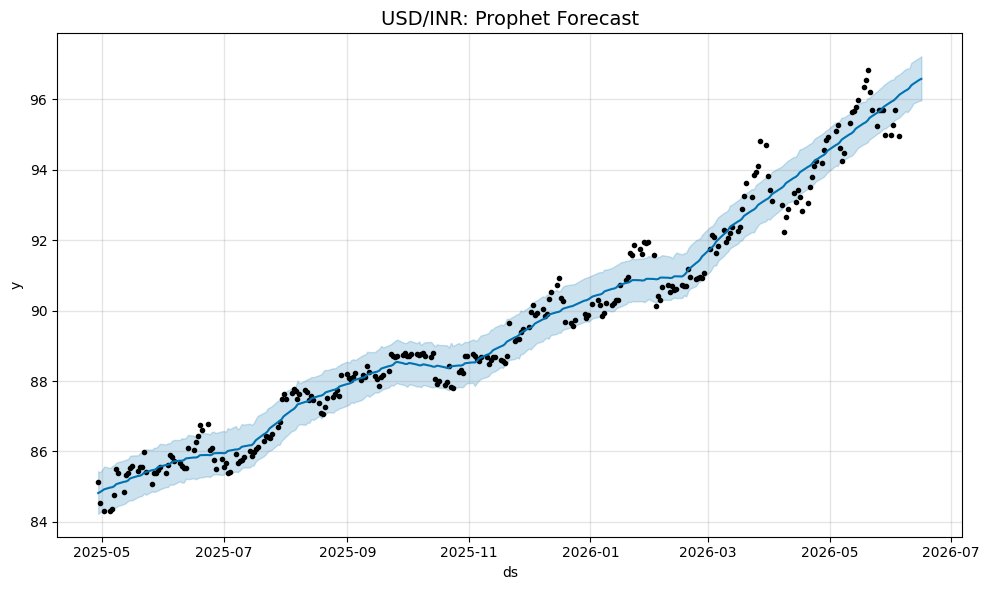

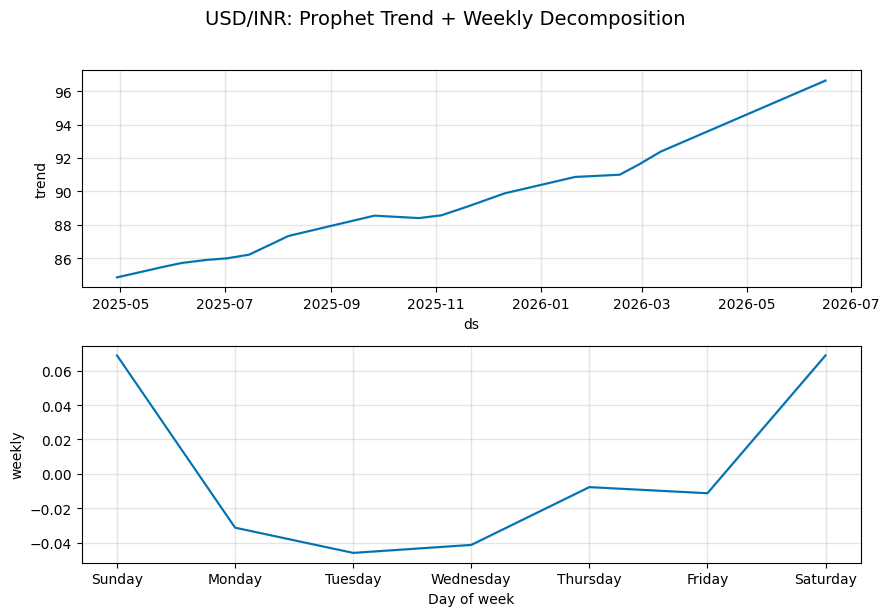


Changepoints detected at:
  2025-05-13
  2025-05-26
  2025-06-06
  2025-06-19
  2025-07-02
  2025-07-15
  2025-07-25
  2025-08-07
  2025-08-20
  2025-09-02
  2025-09-15
  2025-09-26
  2025-10-09
  2025-10-22
  2025-11-04
  2025-11-17
  2025-11-28
  2025-12-11
  2025-12-23
  2026-01-08
  2026-01-21
  2026-02-03
  2026-02-16
  2026-02-27
  2026-03-12

These are dates where Prophet detected the trend shifted.
Useful for your narrative: 'INR depreciation accelerated on [date]'


In [ ]:
series = df['usd_inr'].dropna()
model = fit_prophet(series, variant='basic')

future = model.make_future_dataframe(periods=7, freq='B')
forecast = model.predict(future)

# Prophet's built-in plot
fig1 = model.plot(forecast)
plt.title('USD/INR: Prophet Forecast', fontsize=14)
plt.tight_layout()
plt.savefig('prophet_forecast_usdinr.png', dpi=150, bbox_inches='tight')
plt.show()

# Component decomposition — Prophet's unique strength
fig2 = model.plot_components(forecast)
plt.suptitle('USD/INR: Prophet Trend + Weekly Decomposition', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('prophet_components_usdinr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChangepoints detected at:")
for cp in model.changepoints:
    print(f"  {cp.strftime('%Y-%m-%d')}")

print(f"\nThese are dates where Prophet detected the trend shifted.")

In [14]:
import warnings
warnings.filterwarnings('ignore')

def walk_forward_prophet(series, events_df=None, variant='basic', 
                         forecast_horizon=1, test_days=60):
    """
    Walk-forward evaluation for Prophet.
    
    Variants:
      basic:    trend + weekly seasonality only
      events:   adds central bank meeting events (US + relevant other side)
    """
    series = series.dropna()
    
    if len(series) < test_days + 90:
        return None
    
    results = []
    
    # Prepare holidays dataframe based on variant
    holidays_df = None
    if variant == 'events' and events_df is not None and len(events_df) > 0:
        # All events in events_df are now central bank meetings (we removed retail holidays)
        holidays_df = events_df[['ds', 'holiday', 'lower_window', 'upper_window']].copy()
    
    for i in range(test_days, 0, -1):
        train = series[:-i]
        actual_value = series.iloc[-i]
        naive_value = train.iloc[-1]
        
        prophet_df = pd.DataFrame({
            'ds': train.index,
            'y': train.values
        })
        
        model = Prophet(
            daily_seasonality=False,
            weekly_seasonality=True,
            yearly_seasonality=False,
            changepoint_prior_scale=0.05,
            interval_width=0.80,
            holidays=holidays_df
        )
        
        model.fit(prophet_df)
        
        future = model.make_future_dataframe(periods=forecast_horizon, freq='B')
        forecast = model.predict(future)
        
        last_row = forecast.iloc[-1]
        forecast_value = last_row['yhat']
        forecast_lower = last_row['yhat_lower']
        forecast_upper = last_row['yhat_upper']
        
        actual_direction = 1 if actual_value > train.iloc[-1] else 0
        forecast_direction = 1 if forecast_value > train.iloc[-1] else 0
        
        results.append({
            'date': series.index[-i],
            'actual': actual_value,
            'naive': naive_value,
            'forecast': forecast_value,
            'forecast_lower': forecast_lower,
            'forecast_upper': forecast_upper,
            'naive_error': abs(actual_value - naive_value),
            'forecast_error': abs(actual_value - forecast_value),
            'actual_direction': actual_direction,
            'forecast_direction': forecast_direction
        })
    
    return pd.DataFrame(results)


print("Running walk-forward evaluation...")
print("This takes ~10-15 min (Prophet refits 60 times per pair per variant)\n")

prophet_evaluation = {}

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    events = events_by_pair.get(col)
    prophet_evaluation[col] = {}
    
    # Just two variants now: basic vs basic+events
    for variant in ['basic', 'events']:
        print(f"  {col.upper()} — {variant}...", end=" ", flush=True)
        result = walk_forward_prophet(
            df[col], events_df=events, variant=variant,
            forecast_horizon=1, test_days=60
        )
        if result is not None:
            prophet_evaluation[col][variant] = result
            acc = (result['actual_direction'] == result['forecast_direction']).mean() * 100
            print(f"done — direction: {acc:.1f}%")
        else:
            print("skipped")

print("\nAll evaluations complete")

Running walk-forward evaluation...
This takes ~10-15 min (Prophet refits 60 times per pair per variant)

  USD_INR — basic... 

11:46:57 - cmdstanpy - INFO - Chain [1] start processing
11:46:57 - cmdstanpy - INFO - Chain [1] done processing
11:46:58 - cmdstanpy - INFO - Chain [1] start processing
11:46:58 - cmdstanpy - INFO - Chain [1] done processing
11:46:58 - cmdstanpy - INFO - Chain [1] start processing
11:46:59 - cmdstanpy - INFO - Chain [1] done processing
11:46:59 - cmdstanpy - INFO - Chain [1] start processing
11:47:00 - cmdstanpy - INFO - Chain [1] done processing
11:47:00 - cmdstanpy - INFO - Chain [1] start processing
11:47:01 - cmdstanpy - INFO - Chain [1] done processing
11:47:01 - cmdstanpy - INFO - Chain [1] start processing
11:47:01 - cmdstanpy - INFO - Chain [1] done processing
11:47:02 - cmdstanpy - INFO - Chain [1] start processing
11:47:02 - cmdstanpy - INFO - Chain [1] done processing
11:47:03 - cmdstanpy - INFO - Chain [1] start processing
11:47:03 - cmdstanpy - INFO - Chain [1] done processing
11:47:04 - cmdstanpy - INFO - Chain [1] start processing
11:47:04 - cmdstanpy - INFO - Chain [1]

done — direction: 41.7%
  USD_INR — events... 

11:47:35 - cmdstanpy - INFO - Chain [1] start processing
11:47:35 - cmdstanpy - INFO - Chain [1] done processing
11:47:36 - cmdstanpy - INFO - Chain [1] start processing
11:47:36 - cmdstanpy - INFO - Chain [1] done processing
11:47:37 - cmdstanpy - INFO - Chain [1] start processing
11:47:37 - cmdstanpy - INFO - Chain [1] done processing
11:47:38 - cmdstanpy - INFO - Chain [1] start processing
11:47:38 - cmdstanpy - INFO - Chain [1] done processing
11:47:38 - cmdstanpy - INFO - Chain [1] start processing
11:47:38 - cmdstanpy - INFO - Chain [1] done processing
11:47:39 - cmdstanpy - INFO - Chain [1] start processing
11:47:39 - cmdstanpy - INFO - Chain [1] done processing
11:47:40 - cmdstanpy - INFO - Chain [1] start processing
11:47:40 - cmdstanpy - INFO - Chain [1] done processing
11:47:41 - cmdstanpy - INFO - Chain [1] start processing
11:47:41 - cmdstanpy - INFO - Chain [1] done processing
11:47:41 - cmdstanpy - INFO - Chain [1] start processing
11:47:42 - cmdstanpy - INFO - Chain [1]

done — direction: 48.3%
  USD_EUR — basic... 

...

done — direction: 48.3%
  USD_PHP — basic... 

11:52:17 - cmdstanpy - INFO - Chain [1] start processing
11:52:17 - cmdstanpy - INFO - Chain [1] done processing
11:52:18 - cmdstanpy - INFO - Chain [1] start processing
11:52:18 - cmdstanpy - INFO - Chain [1] done processing
11:52:18 - cmdstanpy - INFO - Chain [1] start processing
11:52:18 - cmdstanpy - INFO - Chain [1] done processing
11:52:19 - cmdstanpy - INFO - Chain [1] start processing
11:52:19 - cmdstanpy - INFO - Chain [1] done processing
11:52:20 - cmdstanpy - INFO - Chain [1] start processing
11:52:20 - cmdstanpy - INFO - Chain [1] done processing
11:52:20 - cmdstanpy - INFO - Chain [1] start processing
11:52:21 - cmdstanpy - INFO - Chain [1] done processing
11:52:21 - cmdstanpy - INFO - Chain [1] start processing
11:52:21 - cmdstanpy - INFO - Chain [1] done processing
11:52:22 - cmdstanpy - INFO - Chain [1] start processing
11:52:22 - cmdstanpy - INFO - Chain [1] done processing
11:52:22 - cmdstanpy - INFO - Chain [1] start processing
11:52:23 - cmdstanpy - INFO - Chain [1]

done — direction: 55.0%
  USD_PHP — events... 

11:52:58 - cmdstanpy - INFO - Chain [1] start processing
11:52:59 - cmdstanpy - INFO - Chain [1] done processing
11:52:59 - cmdstanpy - INFO - Chain [1] start processing
11:52:59 - cmdstanpy - INFO - Chain [1] done processing
11:53:00 - cmdstanpy - INFO - Chain [1] start processing
11:53:00 - cmdstanpy - INFO - Chain [1] done processing
11:53:01 - cmdstanpy - INFO - Chain [1] start processing
11:53:01 - cmdstanpy - INFO - Chain [1] done processing
11:53:02 - cmdstanpy - INFO - Chain [1] start processing
11:53:02 - cmdstanpy - INFO - Chain [1] done processing
11:53:02 - cmdstanpy - INFO - Chain [1] start processing
11:53:03 - cmdstanpy - INFO - Chain [1] done processing
11:53:03 - cmdstanpy - INFO - Chain [1] start processing
11:53:03 - cmdstanpy - INFO - Chain [1] done processing
11:53:04 - cmdstanpy - INFO - Chain [1] start processing
11:53:04 - cmdstanpy - INFO - Chain [1] done processing
11:53:05 - cmdstanpy - INFO - Chain [1] start processing
11:53:05 - cmdstanpy - INFO - Chain [1]

done — direction: 60.0%

All evaluations complete


In [15]:
print("=== Prophet Variants vs Chronos-Bolt vs Naive Baseline ===\n")

all_rows = []

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    # Baseline
    for variant_name, result in prophet_evaluation[col].items():
        naive_mae = result['naive_error'].mean()
        model_mae = result['forecast_error'].mean()
        theil_u = model_mae / naive_mae
        direction_acc = (result['actual_direction'] == result['forecast_direction']).mean() * 100
        
        # Interval calibration
        in_interval = ((result['actual'] >= result['forecast_lower']) & 
                       (result['actual'] <= result['forecast_upper'])).mean() * 100
        
        all_rows.append({
            'pair': col.upper(),
            'model': f'Prophet-{variant_name}',
            'theil_u': theil_u,
            'direction_acc': direction_acc,
            'interval_coverage': in_interval
        })
    
    # Add Chronos results for comparison
    if col in chronos_results:
        all_rows.append({
            'pair': col.upper(),
            'model': 'Chronos-Bolt',
            'theil_u': chronos_results[col]['theil_u'],
            'direction_acc': chronos_results[col]['direction_accuracy'] * 100,
            'interval_coverage': chronos_results[col].get('interval_coverage_80', 0) * 100
        })

comparison = pd.DataFrame(all_rows)

# Print per pair
for pair in ['USD_INR', 'USD_EUR', 'USD_GBP', 'USD_MXN', 'USD_PHP']:
    print(f"\n{pair}:")
    subset = comparison[comparison['pair'] == pair]
    print(subset[['model', 'theil_u', 'direction_acc', 'interval_coverage']].to_string(index=False))

=== Prophet Variants vs Chronos-Bolt vs Naive Baseline ===


USD_INR:
         model  theil_u  direction_acc  interval_coverage
 Prophet-basic 2.110841      41.666667          48.333333
Prophet-events 2.087639      48.333333          45.000000
  Chronos-Bolt 0.993851      63.333333           0.000000

USD_EUR:
         model  theil_u  direction_acc  interval_coverage
 Prophet-basic 3.615404      53.333333          48.333333
Prophet-events 3.704194      53.333333          46.666667
  Chronos-Bolt 1.059004      46.666667           0.000000

USD_GBP:
         model  theil_u  direction_acc  interval_coverage
 Prophet-basic 2.838497      63.333333               45.0
Prophet-events 2.865319      61.666667               45.0
  Chronos-Bolt 1.006491      51.666667                0.0

USD_MXN:
         model  theil_u  direction_acc  interval_coverage
 Prophet-basic 3.612184      51.666667          38.333333
Prophet-events 3.688936      48.333333          38.333333
  Chronos-Bolt 0.966197      5

In [16]:
print("=== Did Adding Central Bank Events Improve Prophet? ===\n")

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    print(f"{col.upper()}:")
    
    basic = prophet_evaluation[col]['basic']
    events = prophet_evaluation[col]['events']
    
    basic_acc = (basic['actual_direction'] == basic['forecast_direction']).mean() * 100
    events_acc = (events['actual_direction'] == events['forecast_direction']).mean() * 100
    
    basic_theil = basic['forecast_error'].mean() / basic['naive_error'].mean()
    events_theil = events['forecast_error'].mean() / events['naive_error'].mean()
    
    print(f"  Basic:   Theil U = {basic_theil:.4f}   Direction = {basic_acc:.1f}%")
    print(f"  Events:  Theil U = {events_theil:.4f}   Direction = {events_acc:.1f}%")
    
    if events_acc > basic_acc + 2:
        print(f"  → Events improved direction by {events_acc - basic_acc:.1f}pp ✓")
    elif events_acc < basic_acc - 2:
        print(f"  → Events HURT by {basic_acc - events_acc:.1f}pp ✗")
    else:
        print(f"  → Events made no meaningful difference")
    print()

print("Note: 60 test days is small for detecting event-specific patterns.")
print("Even if effect exists, it may not be statistically detectable here.")

=== Did Adding Central Bank Events Improve Prophet? ===

USD_INR:
  Basic:   Theil U = 2.1108   Direction = 41.7%
  Events:  Theil U = 2.0876   Direction = 48.3%
  → Events improved direction by 6.7pp ✓

USD_EUR:
  Basic:   Theil U = 3.6154   Direction = 53.3%
  Events:  Theil U = 3.7042   Direction = 53.3%
  → Events made no meaningful difference

USD_GBP:
  Basic:   Theil U = 2.8385   Direction = 63.3%
  Events:  Theil U = 2.8653   Direction = 61.7%
  → Events made no meaningful difference

USD_MXN:
  Basic:   Theil U = 3.6122   Direction = 51.7%
  Events:  Theil U = 3.6889   Direction = 48.3%
  → Events HURT by 3.3pp ✗

USD_PHP:
  Basic:   Theil U = 2.4809   Direction = 55.0%
  Events:  Theil U = 2.3982   Direction = 60.0%
  → Events improved direction by 5.0pp ✓

Note: 60 test days is small for detecting event-specific patterns.
Even if effect exists, it may not be statistically detectable here.


=== Changepoint Detection Across All Pairs ===

Prophet automatically detects where the trend shifted.



12:00:18 - cmdstanpy - INFO - Chain [1] start processing
12:00:18 - cmdstanpy - INFO - Chain [1] done processing
12:00:19 - cmdstanpy - INFO - Chain [1] start processing
12:00:19 - cmdstanpy - INFO - Chain [1] done processing
12:00:19 - cmdstanpy - INFO - Chain [1] start processing
12:00:19 - cmdstanpy - INFO - Chain [1] done processing
12:00:20 - cmdstanpy - INFO - Chain [1] start processing
12:00:20 - cmdstanpy - INFO - Chain [1] done processing
12:00:20 - cmdstanpy - INFO - Chain [1] start processing
12:00:21 - cmdstanpy - INFO - Chain [1] done processing


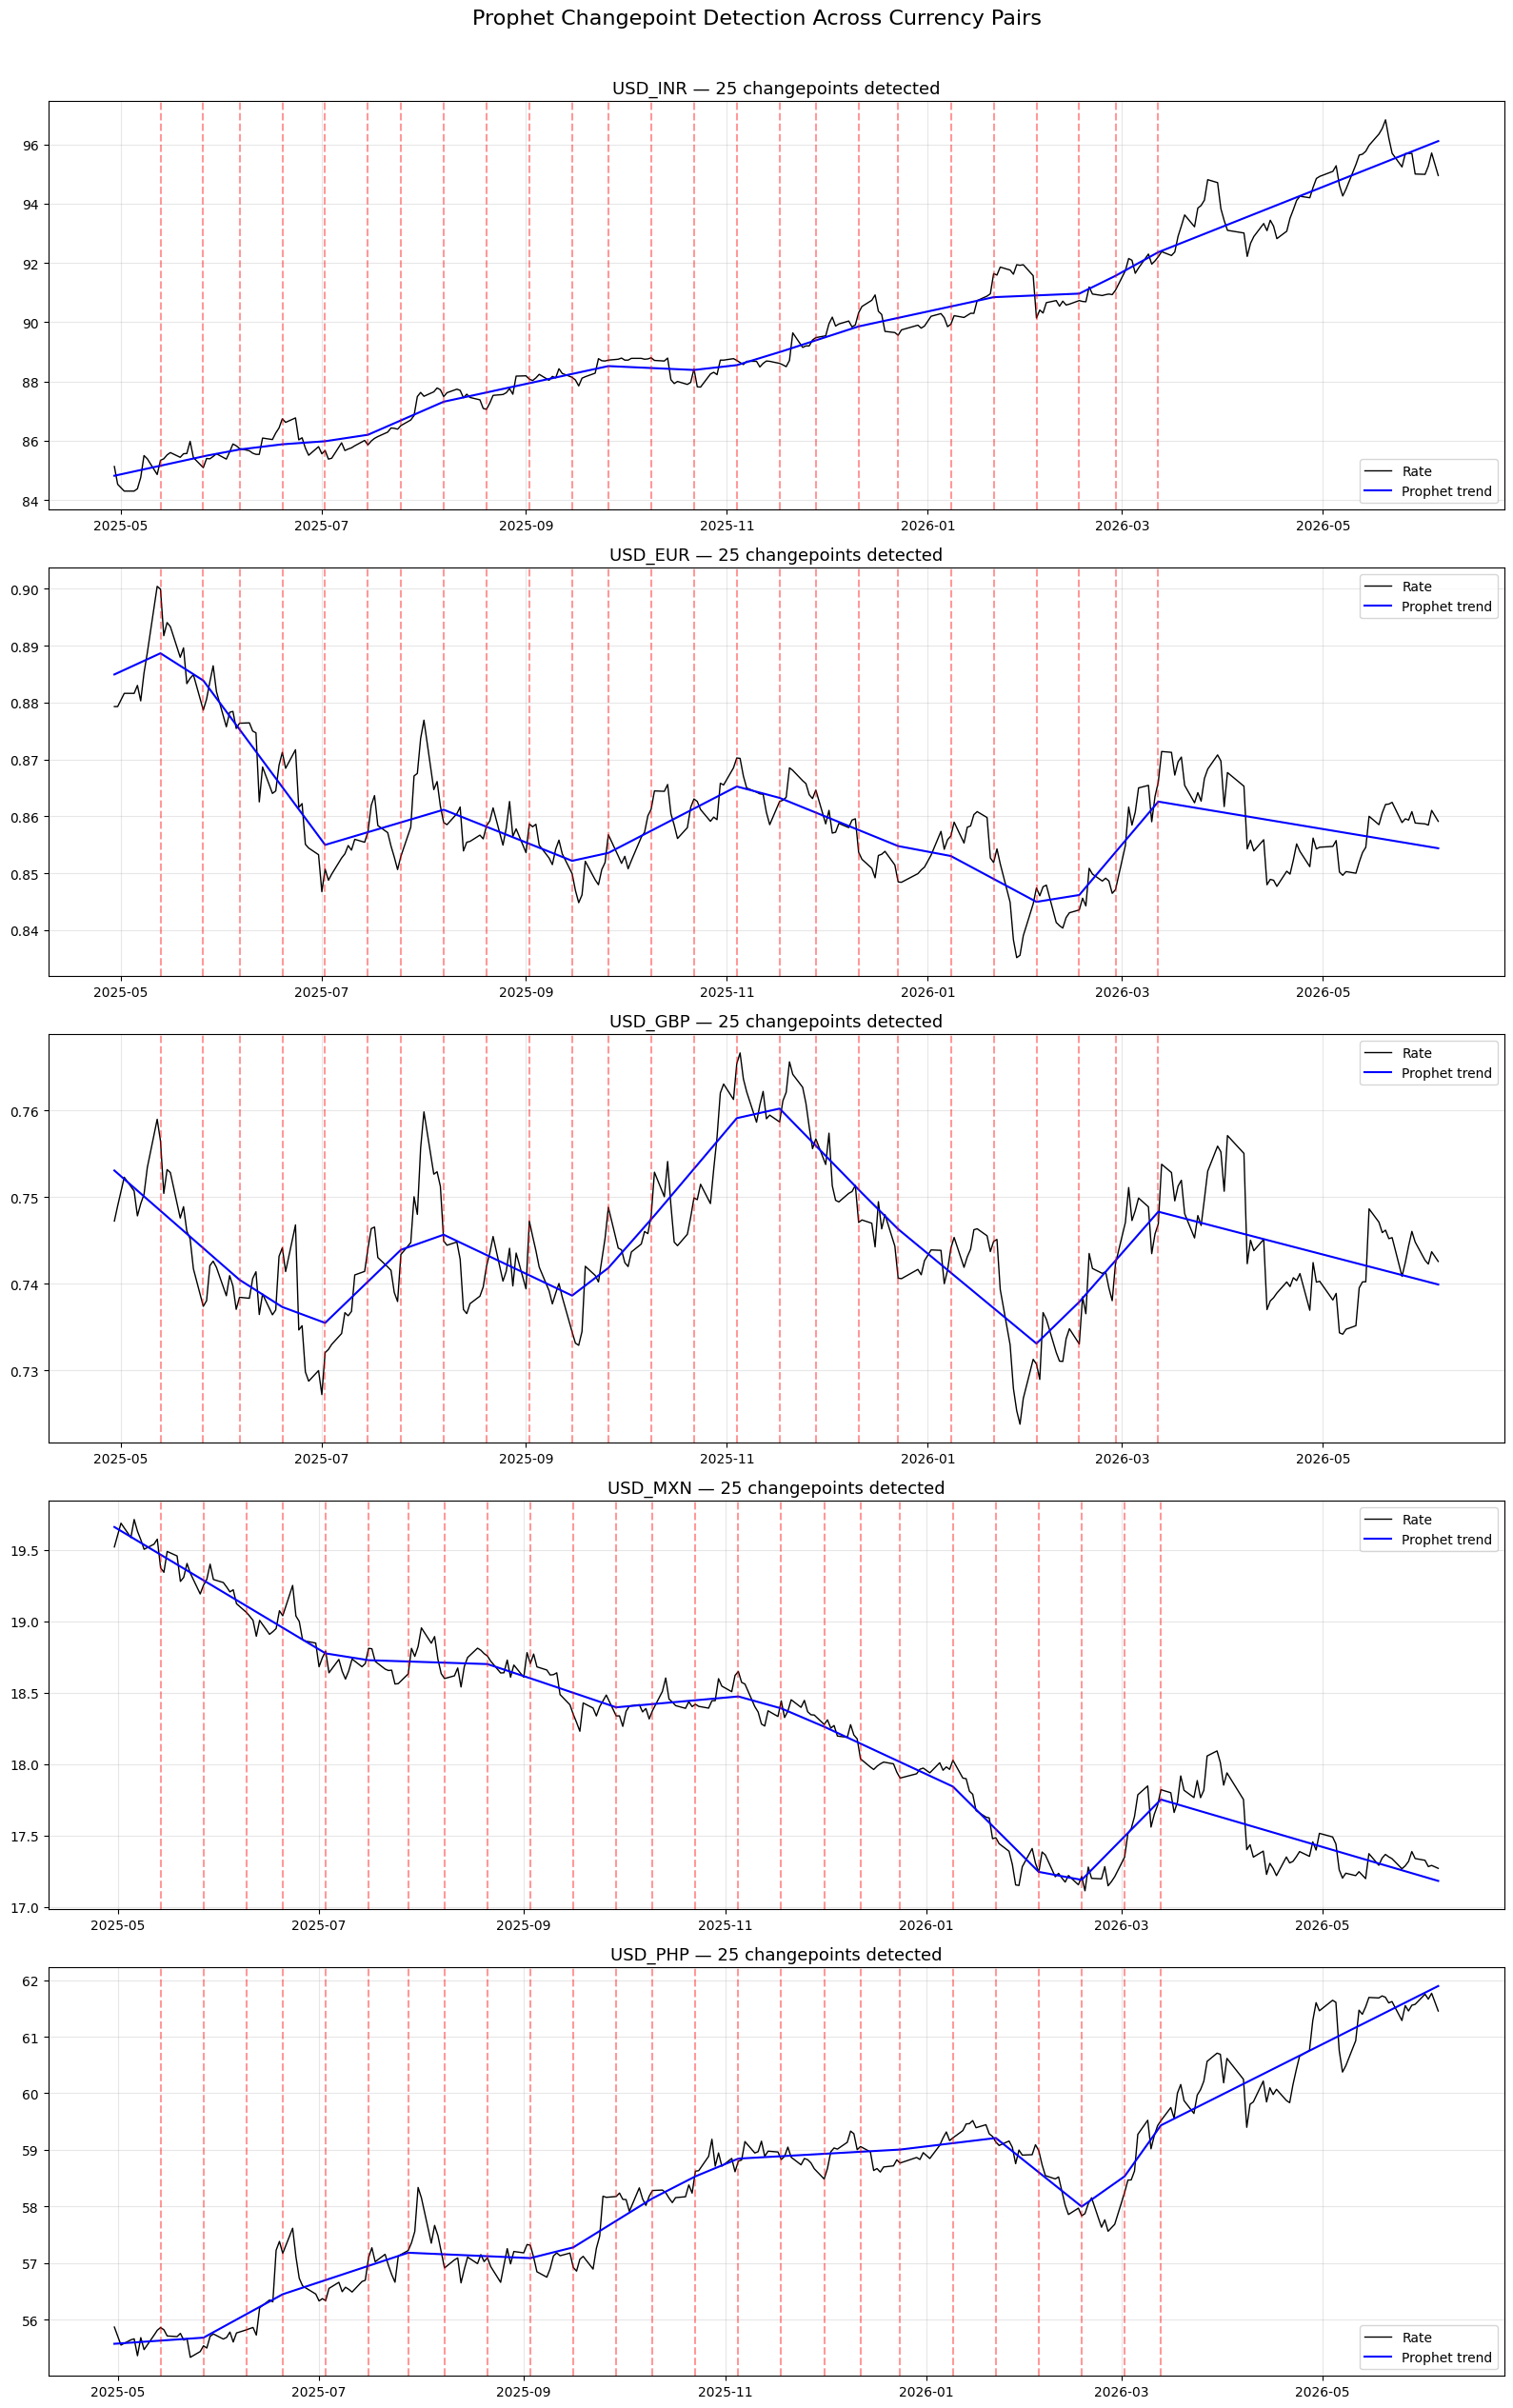


Changepoint dates (for narrative layer):



12:00:25 - cmdstanpy - INFO - Chain [1] start processing
12:00:26 - cmdstanpy - INFO - Chain [1] done processing
12:00:26 - cmdstanpy - INFO - Chain [1] start processing


USD_INR: 25 changepoints
  2025-05-13
  2025-05-26
  2025-06-06
  2025-06-19
  2025-07-02
  2025-07-15
  2025-07-25
  2025-08-07
  2025-08-20
  2025-09-02
  2025-09-15
  2025-09-26
  2025-10-09
  2025-10-22
  2025-11-04
  2025-11-17
  2025-11-28
  2025-12-11
  2025-12-23
  2026-01-08
  2026-01-21
  2026-02-03
  2026-02-16
  2026-02-27
  2026-03-12



12:00:26 - cmdstanpy - INFO - Chain [1] done processing
12:00:26 - cmdstanpy - INFO - Chain [1] start processing


USD_EUR: 25 changepoints
  2025-05-13
  2025-05-26
  2025-06-06
  2025-06-19
  2025-07-02
  2025-07-15
  2025-07-25
  2025-08-07
  2025-08-20
  2025-09-02
  2025-09-15
  2025-09-26
  2025-10-09
  2025-10-22
  2025-11-04
  2025-11-17
  2025-11-28
  2025-12-11
  2025-12-23
  2026-01-08
  2026-01-21
  2026-02-03
  2026-02-16
  2026-02-27
  2026-03-12



...

USD_GBP: 25 changepoints
  2025-05-13
  2025-05-26
  2025-06-06
  2025-06-19
  2025-07-02
  2025-07-15
  2025-07-25
  2025-08-07
  2025-08-20
  2025-09-02
  2025-09-15
  2025-09-26
  2025-10-09
  2025-10-22
  2025-11-04
  2025-11-17
  2025-11-28
  2025-12-11
  2025-12-23
  2026-01-08
  2026-01-21
  2026-02-03
  2026-02-16
  2026-02-27
  2026-03-12



12:00:27 - cmdstanpy - INFO - Chain [1] done processing
12:00:27 - cmdstanpy - INFO - Chain [1] start processing


USD_MXN: 25 changepoints
  2025-05-14
  2025-05-27
  2025-06-09
  2025-06-20
  2025-07-03
  2025-07-16
  2025-07-28
  2025-08-08
  2025-08-21
  2025-09-03
  2025-09-16
  2025-09-29
  2025-10-10
  2025-10-23
  2025-11-05
  2025-11-18
  2025-12-01
  2025-12-12
  2025-12-24
  2026-01-09
  2026-01-22
  2026-02-04
  2026-02-17
  2026-03-02
  2026-03-13



12:00:27 - cmdstanpy - INFO - Chain [1] done processing


USD_PHP: 25 changepoints
  2025-05-14
  2025-05-27
  2025-06-09
  2025-06-20
  2025-07-03
  2025-07-16
  2025-07-28
  2025-08-08
  2025-08-21
  2025-09-03
  2025-09-16
  2025-09-29
  2025-10-10
  2025-10-23
  2025-11-05
  2025-11-18
  2025-12-01
  2025-12-12
  2025-12-24
  2026-01-09
  2026-01-22
  2026-02-04
  2026-02-17
  2026-03-02
  2026-03-13



In [17]:
print("=== Changepoint Detection Across All Pairs ===\n")
print("Prophet automatically detects where the trend shifted.\n")

fig, axes = plt.subplots(5, 1, figsize=(16, 25))

for i, col in enumerate(['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']):
    series = df[col].dropna()
    prophet_df = pd.DataFrame({'ds': series.index, 'y': series.values})
    
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=False,
        changepoint_prior_scale=0.05
    )
    model.fit(prophet_df)
    
    future = model.make_future_dataframe(periods=0, freq='B')
    forecast = model.predict(future)
    
    # Plot
    axes[i].plot(series.index, series.values, color='black', linewidth=1, label='Rate')
    axes[i].plot(forecast['ds'], forecast['trend'], color='blue', linewidth=1.5, label='Prophet trend')
    
    # Mark changepoints
    for cp in model.changepoints:
        axes[i].axvline(cp, color='red', linestyle='--', alpha=0.4)
    
    axes[i].set_title(f'{col.upper()} — {len(model.changepoints)} changepoints detected', fontsize=13)
    axes[i].legend(loc='best')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Prophet Changepoint Detection Across Currency Pairs', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('prophet_changepoints_all.png', dpi=150, bbox_inches='tight')
plt.show()

# Print changepoint dates for narrative use
print("\nChangepoint dates (for narrative layer):\n")
for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    series = df[col].dropna()
    prophet_df = pd.DataFrame({'ds': series.index, 'y': series.values})
    
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=False,
        changepoint_prior_scale=0.05
    )
    model.fit(prophet_df)
    
    print(f"{col.upper()}: {len(model.changepoints)} changepoints")
    for cp in model.changepoints:
        print(f"  {cp.strftime('%Y-%m-%d')}")
    print()

In [19]:
from scipy import stats

print("=== Statistical Significance of Event Variant Improvements ===\n")

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    basic = prophet_evaluation[col]['basic']
    events = prophet_evaluation[col]['events']
    
    basic_correct = (basic['actual_direction'] == basic['forecast_direction']).sum()
    events_correct = (events['actual_direction'] == events['forecast_direction']).sum()
    n = len(basic)
    
    basic_acc = basic_correct / n
    events_acc = events_correct / n
    
    # McNemar-style test: compare paired binary outcomes
    # H0: both variants have same accuracy
    # Using a simpler binomial test on the difference
    diff = events_correct - basic_correct
    p_value_one_sided = 1 - stats.binom.cdf(abs(diff) - 1, n, 0.5)
    
    # Also test if events variant is itself significantly above 50%
    p_events_vs_50 = 1 - stats.binom.cdf(events_correct - 1, n, 0.5)
    
    print(f"{col.upper()}:")
    print(f"  Basic:  {basic_correct}/{n} = {basic_acc*100:.1f}%")
    print(f"  Events: {events_correct}/{n} = {events_acc*100:.1f}%")
    print(f"  Difference: {diff} correct predictions")
    print(f"  P(events > 50%): {p_events_vs_50:.4f}")
    print()

=== Statistical Significance of Event Variant Improvements ===

USD_INR:
  Basic:  25/60 = 41.7%
  Events: 29/60 = 48.3%
  Difference: 4 correct predictions
  P(events > 50%): 0.6506

USD_EUR:
  Basic:  32/60 = 53.3%
  Events: 32/60 = 53.3%
  Difference: 0 correct predictions
  P(events > 50%): 0.3494

USD_GBP:
  Basic:  38/60 = 63.3%
  Events: 37/60 = 61.7%
  Difference: -1 correct predictions
  P(events > 50%): 0.0462

USD_MXN:
  Basic:  31/60 = 51.7%
  Events: 29/60 = 48.3%
  Difference: -2 correct predictions
  P(events > 50%): 0.6506

USD_PHP:
  Basic:  33/60 = 55.0%
  Events: 36/60 = 60.0%
  Difference: 3 correct predictions
  P(events > 50%): 0.0775



In [18]:
prophet_output = {}

for col in prophet_evaluation:
    prophet_output[col] = {}
    for variant, result in prophet_evaluation[col].items():
        naive_mae = result['naive_error'].mean()
        model_mae = result['forecast_error'].mean()
        
        in_interval = ((result['actual'] >= result['forecast_lower']) & 
                       (result['actual'] <= result['forecast_upper'])).mean()
        
        prophet_output[col][variant] = {
            'model': f'prophet-{variant}',
            'test_days': len(result),
            'naive_mae': float(naive_mae),
            'prophet_mae': float(model_mae),
            'theil_u': float(model_mae / naive_mae),
            'direction_accuracy': float((result['actual_direction'] == result['forecast_direction']).mean()),
            'interval_coverage_80': float(in_interval)
        }

with open('prophet_results.json', 'w') as f:
    json.dump(prophet_output, f, indent=2)

print("Prophet results saved to prophet_results.json")
print("\nNext: notebook 05 — GARCH volatility forecasting")

Prophet results saved to prophet_results.json

Next: notebook 05 — GARCH volatility forecasting
